In [1]:
# Reads in FITS files from the MCT and checks them

In [1]:
from astropy.io import fits
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.visualization import ZScaleInterval


%matplotlib inline

In [2]:
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260331/up_the_ramp/'
stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407154830/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155057/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155147/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/'
#stem = '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155336/'

In [3]:
def plot_mct_readouts(dir_name, data_cube, slopes, intercepts):
    
    fig, axs = plt.subplots(1, 4, figsize=(20, 4), constrained_layout=True)
    im0 = axs[0].imshow(data_cube[-1, :, :], origin='lower', cmap='gray')
    axs[0].set_xlabel('x (pix)')
    axs[0].set_ylabel('y (pix)')
    axs[0].set_title('Last read in ramp')
    fig.colorbar(im0, ax=axs[0], label='counts')

    im1 = axs[1].imshow(slopes, origin='lower', cmap='gray', norm=LogNorm())
    axs[1].set_xlabel('x (pix)')
    axs[1].set_ylabel('y (pix)')
    axs[1].set_title('Slopes (log color scale)')
    fig.colorbar(im1, ax=axs[1], label='counts/read')

    zscale = ZScaleInterval()
    vmin, vmax = zscale.get_limits(slopes)
    im2 = axs[2].imshow(
        slopes,
        origin='lower',
        cmap='gray',
        vmin=vmin,
        vmax=vmax,
    )
    axs[2].set_xlabel('x (pix)')
    axs[2].set_ylabel('y (pix)')
    axs[2].set_title('Slopes (z color scale)')
    fig.colorbar(im2, ax=axs[2], label='counts/read')

    im3 = axs[3].imshow(intercepts, origin='lower', cmap='gray')
    axs[3].set_xlabel('x (pix)')
    axs[3].set_ylabel('y (pix)')
    axs[3].set_title('Y-intercepts')
    fig.colorbar(im3, ax=axs[3], label='counts')
    plt.suptitle(dir_name)
    #plt.show()
    plt.savefig(dir_name + '.png')
    plt.close()
    return

In [11]:
size_window = 2048
subdirs = [d for d in os.listdir(stem) if os.path.isdir(os.path.join(stem, d))]
print(subdirs)
for sub in subdirs[0:1]:
    
    file_name_list = glob.glob(stem + sub + '/*.fits')
    print(stem + sub)
    print(file_name_list)
    file_name_list = sorted(file_name_list)

    # read in each 2D frame into a 3D cube
    # read in a test frame to get the shape of the data
    data_test = fits.open(file_name_list[0])[0].data
    # make a 3D cube of the data
    data_cube = np.zeros((len(file_name_list), data_test.shape[0], data_test.shape[1]))
    for i, file_name in enumerate(file_name_list):
        hdul = fits.open(file_name)
        data_cube[i, :, :] = hdul[0].data

    # make a linear fit to the pixels for each pixel
    idx_frames = np.arange(len(file_name_list))
    x = np.asarray(idx_frames)
    
    Y2 = data_cube[:, :size_window, :size_window].reshape(len(x), -1)
    A = np.vstack([x, np.ones_like(x)]).T
    coeffs, _, _, _ = np.linalg.lstsq(A, Y2, rcond=None)
    slopes = coeffs[0].reshape(size_window, size_window)
    intercepts = coeffs[1].reshape(size_window, size_window)

    _ = plot_mct_readouts(dir_name=sub, data_cube=data_cube, slopes=slopes, intercepts=intercepts)

['20260407155243', '20260407155336', '20260407154830', '20260407155147', '20260407155057']
/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243
['/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/H2RG_R01_M01_N08.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/H2RG_R01_M01_N12.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/H2RG_R01_M01_N04.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/H2RG_R01_M01_N05.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/H2RG_R01_M01_N13.fits', '/Users/eckhartspalding/Documents/job_science/postdoc_eth/nice/mct_detector/eckhart_20260407/20260407155243/H2RG_R01_M01_N09.fits', '/Users/e

In [10]:
subdirs

['20260407155243',
 '20260407155336',
 '20260407154830',
 '20260407155147',
 '20260407155057']

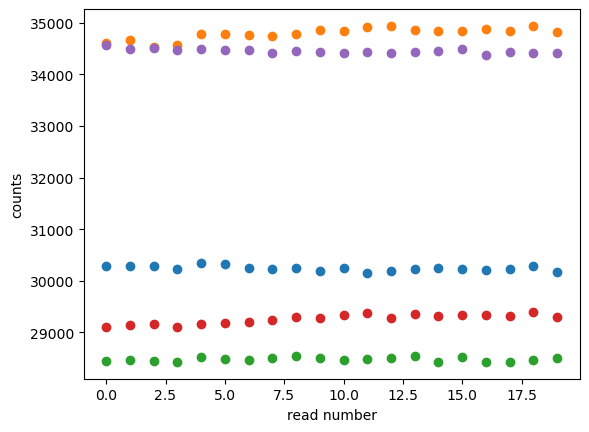

In [15]:
# plot five pixel responses, with N_, M_, randomly chosen from within the cube:
for i in range(5):
    N_ = np.random.randint(0, size_window)
    M_ = np.random.randint(0, size_window)
    plt.scatter(x, data_cube[:,N_,M_])
plt.xlabel('read number')
plt.ylabel('counts')
plt.savefig('pixel_responses.png')  

In [ ]:
# take one file, see pixel reponse

file_name_list = glob.glob(stem + sub + '/*.fits')